# Local Evaluation: Error Analysis + Baseline vs Best

This notebook focuses on local evaluation using the official dev set:
- Error analysis with examples
- Custom metrics (confusion matrix, precision-recall curve, threshold search)
- Baseline vs best model comparison

In [21]:
import os
import random
import re
import numpy as np
import pandas as pd
import torch
import nltk
from nltk.corpus import wordnet
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    RobertaConfig,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    f1_score,
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

DATA_PATH = os.path.join(os.getcwd(), "data")

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [22]:
pcl_df = pd.read_csv(
    os.path.join(DATA_PATH, "dontpatronizeme_pcl.tsv"),
    delimiter="\t",
    header=None,
)
pcl_df.columns = ["paragraph_id", "article_id", "keyword", "country_code", "paragraph", "label"]
pcl_df["y"] = pcl_df["label"].apply(lambda x: 0 if x < 2 else 1)
pcl_df["paragraph"] = pcl_df["paragraph"].fillna("").astype(str)

train_ids = pd.read_csv(os.path.join(DATA_PATH, "train_semeval_parids-labels.csv"))
dev_ids = pd.read_csv(os.path.join(DATA_PATH, "dev_semeval_parids-labels.csv"))

train_df = pd.merge(pcl_df, train_ids, how="right", left_on="paragraph_id", right_on="par_id")
dev_df = pd.merge(pcl_df, dev_ids, how="right", left_on="paragraph_id", right_on="par_id")

print("Train size:", train_df.shape)
print("Dev size:", dev_df.shape)
print("Train label counts:")
print(train_df["y"].value_counts().sort_index())

Train size: (8375, 9)
Dev size: (2094, 9)
Train label counts:
y
0    7581
1     794
Name: count, dtype: int64


## Data augmentation (for best model)
This mirrors the augmentation in the best model notebook so the comparison stays fair.

In [23]:
def _synonym_candidates(word):
    syns = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            name = lemma.name().replace("_", " ").lower()
            if name != word.lower() and name.isalpha():
                syns.add(name)
    return list(syns)

def augment_text(text, replace_n=2):
    tokens = re.findall(r"[A-Za-z]+|[^A-Za-z]+", text)
    word_indices = [i for i, t in enumerate(tokens) if t.isalpha() and len(t) > 3]
    if not word_indices:
        return text
    random.shuffle(word_indices)
    replaced = 0
    for idx in word_indices:
        word = tokens[idx]
        candidates = _synonym_candidates(word)
        if candidates:
            tokens[idx] = random.choice(candidates)
            replaced += 1
        if replaced >= replace_n:
            break
    return "".join(tokens)

def build_train_df(augment_factor, replace_n, neg_pos_ratio=None):
    train_base = train_df.reset_index(drop=True).sample(frac=1, random_state=RNG_SEED)
    pos_df = train_base[train_base["y"] == 1].copy()
    augmented_rows = []
    for _ in range(augment_factor):
        aug = pos_df.copy()
        aug["paragraph"] = aug["paragraph"].apply(lambda x: augment_text(x, replace_n=replace_n))
        augmented_rows.append(aug)

    if augmented_rows:
        train_aug = pd.concat([train_base] + augmented_rows).sample(frac=1, random_state=RNG_SEED).reset_index(drop=True)
    else:
        train_aug = train_base.copy()

    if neg_pos_ratio is None:
        train_final = train_aug
    else:
        pos_aug = train_aug[train_aug["y"] == 1].copy()
        neg_aug = train_aug[train_aug["y"] == 0].copy()
        neg_target = min(len(neg_aug), int(len(pos_aug) * neg_pos_ratio))
        neg_sampled = neg_aug.sample(n=neg_target, random_state=RNG_SEED)
        train_final = pd.concat([pos_aug, neg_sampled]).sample(frac=1, random_state=RNG_SEED).reset_index(drop=True)

    class_counts = train_final["y"].value_counts().sort_index()
    num_classes = len(class_counts)
    total = class_counts.sum()
    class_weights = torch.tensor(
        [total / (num_classes * class_counts[i]) for i in range(num_classes)],
        dtype=torch.float,
    )

    return train_final, class_weights

## Tokenization and datasets

In [24]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize(example):
    return tokenizer(
        example["paragraph"],
        truncation=True,
        padding="max_length",
        max_length=256,
    )

def make_dataset(df):
    ds = Dataset.from_pandas(df[["paragraph", "y"]])
    ds = ds.map(tokenize, batched=True)
    ds = ds.rename_column("y", "labels")
    ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    return ds

dev_dataset = make_dataset(dev_df)

/home/ubuntu/Desktop/NLP_IndividualCW/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map:  48%|████▊     | 1000/2094 [00:00<00:00, 1807.72 examples/s]


KeyboardInterrupt: 

## Training / loading models
By default this cell tries to load checkpoints if they exist. Set `RUN_TRAINING = True` to retrain locally.

In [ ]:
RUN_TRAINING = False

BASELINE_DIR = os.path.join(os.getcwd(), "baseline_model")
BEST_DIR = os.path.join(os.getcwd(), "best_model")

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def train_or_load_baseline():
    if not RUN_TRAINING and os.path.isdir(BASELINE_DIR):
        return RobertaForSequenceClassification.from_pretrained(BASELINE_DIR)

    pos_df = train_df[train_df.y == 1]
    neg_df = train_df[train_df.y == 0]
    npos = len(pos_df)
    neg_df_down = neg_df.sample(n=min(npos * 2, len(neg_df)), random_state=RNG_SEED)
    train_balanced = pd.concat([pos_df, neg_df_down]).sample(frac=1, random_state=RNG_SEED)
    train_dataset = make_dataset(train_balanced)

    model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
    args = TrainingArguments(
        output_dir=BASELINE_DIR,
        num_train_epochs=1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        evaluation_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=False,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=dev_dataset,
    )
    trainer.train()
    trainer.save_model(BASELINE_DIR)
    return model

def train_or_load_best():
    if not RUN_TRAINING and os.path.isdir(BEST_DIR):
        return RobertaForSequenceClassification.from_pretrained(BEST_DIR)

    BEST_PARAMS = {
        "aug_factor": 2,
        "replace_n": 1,
        "neg_pos_ratio": 3,
        "learning_rate": 1e-5,
        "epochs": 4,
    }

    train_final, class_weights = build_train_df(
        augment_factor=BEST_PARAMS["aug_factor"],
        replace_n=BEST_PARAMS["replace_n"],
        neg_pos_ratio=BEST_PARAMS["neg_pos_ratio"],
    )
    train_dataset = make_dataset(train_final)

    config = RobertaConfig.from_pretrained(
        "roberta-base",
        num_labels=2,
        classifier_dropout=0.3,
        hidden_dropout_prob=0.2,
    )
    model = RobertaForSequenceClassification.from_pretrained("roberta-base", config=config)

    args = TrainingArguments(
        output_dir=BEST_DIR,
        num_train_epochs=BEST_PARAMS["epochs"],
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        evaluation_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=False,
        learning_rate=BEST_PARAMS["learning_rate"],
        weight_decay=0.05,
        warmup_ratio=0.1,
        report_to="none",
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=dev_dataset,
        class_weights=class_weights,
    )
    trainer.train()
    trainer.save_model(BEST_DIR)
    return model

baseline_model = train_or_load_baseline()
best_model = train_or_load_best()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Predictions on dev

In [ ]:
def predict_probs(model, dataset):
    model.eval()
    trainer = Trainer(model=model)
    pred = trainer.predict(dataset)
    probs = torch.softmax(torch.tensor(pred.predictions), dim=1).numpy()[:, 1]
    return probs

baseline_probs = predict_probs(baseline_model, dev_dataset)
best_probs = predict_probs(best_model, dev_dataset)
labels = dev_df["y"].values

def best_threshold(labels, probs):
    best_f1 = 0.0
    best_t = 0.5
    for t in np.linspace(0.1, 0.9, 81):
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, pos_label=1)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_f1, best_t

baseline_f1, baseline_t = best_threshold(labels, baseline_probs)
best_f1, best_t = best_threshold(labels, best_probs)

print("Baseline best F1", round(baseline_f1, 4), "at t=", round(baseline_t, 2))
print("Best-model best F1", round(best_f1, 4), "at t=", round(best_t, 2))

baseline_preds = (baseline_probs >= baseline_t).astype(int)
best_preds = (best_probs >= best_t).astype(int)

Baseline best F1 0.5347 at t= 0.67
Best-model best F1 0.5966 at t= 0.1


## Custom metrics: confusion matrix + PR curve

Baseline
              precision    recall  f1-score   support

           0      0.962     0.916     0.938      1895
           1      0.450     0.658     0.535       199

    accuracy                          0.891      2094
   macro avg      0.706     0.787     0.737      2094
weighted avg      0.914     0.891     0.900      2094

Confusion matrix:
[[1735  160]
 [  68  131]]


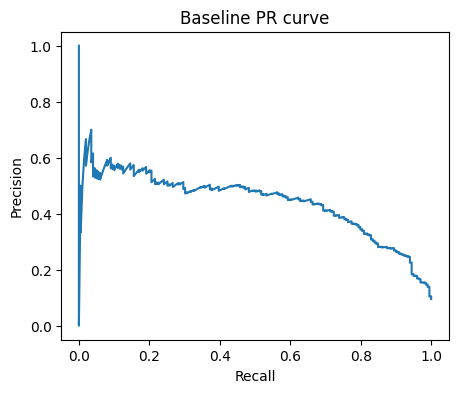

Best model
              precision    recall  f1-score   support

           0      0.959     0.954     0.956      1895
           1      0.581     0.613     0.597       199

    accuracy                          0.921      2094
   macro avg      0.770     0.783     0.776      2094
weighted avg      0.923     0.921     0.922      2094

Confusion matrix:
[[1807   88]
 [  77  122]]


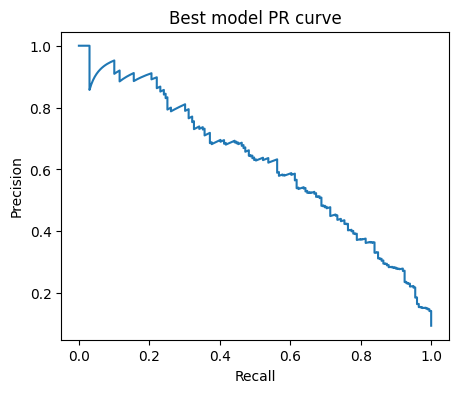

In [ ]:
def show_metrics(name, labels, preds, probs):
    print(name)
    print(classification_report(labels, preds, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(labels, preds))
    prec, rec, _ = precision_recall_curve(labels, probs)
    plt.figure(figsize=(5, 4))
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} PR curve")
    plt.show()

show_metrics("Baseline", labels, baseline_preds, baseline_probs)
show_metrics("Best model", labels, best_preds, best_probs)

## Error analysis: inspect false positives / false negatives

In [ ]:
analysis_df = dev_df.copy()
analysis_df["baseline_prob"] = baseline_probs
analysis_df["baseline_pred"] = baseline_preds
analysis_df["best_prob"] = best_probs
analysis_df["best_pred"] = best_preds
analysis_df["baseline_correct"] = analysis_df["baseline_pred"] == analysis_df["y"]
analysis_df["best_correct"] = analysis_df["best_pred"] == analysis_df["y"]

def show_examples(df, n=5):
    cols = ["paragraph_id", "y", "paragraph", "baseline_pred", "baseline_prob", "best_pred", "best_prob"]
    return df[cols].head(n)

false_pos_best = analysis_df[(analysis_df["y"] == 0) & (analysis_df["best_pred"] == 1)]
false_neg_best = analysis_df[(analysis_df["y"] == 1) & (analysis_df["best_pred"] == 0)]

print("Best model false positives:", len(false_pos_best))
display(show_examples(false_pos_best, n=5))

print("Best model false negatives:", len(false_neg_best))
display(show_examples(false_neg_best, n=5))

Best model false positives: 88


,paragraph_id,y,paragraph,baseline_pred,baseline_prob,best_pred,best_prob
203,8391,0,Marcos said the government should help poor fa...,0,0.664288,1,0.343081
239,8430,0,"There are just on 20,000 members belonging to ...",0,0.570713,1,0.101807
262,8453,0,""" This incident will not tear us down but rath...",1,0.697721,1,0.492342
281,8473,0,The Jali family in Brown 's Farm was elated as...,0,0.603200,1,0.892034
288,8480,0,""" So we do need to heal ourselves as an Aborig...",1,0.697991,1,0.996482


Best model false negatives: 77


,paragraph_id,y,paragraph,baseline_pred,baseline_prob,best_pred,best_prob
0,4046,1,We also know that they can benefit by receivin...,1,0.672155,0,0.000635
2,8330,1,Many refugees do n't want to be resettled anyw...,0,0.069402,0,0.000840
4,4089,1,"In a 90-degree view of his constituency , one ...",0,0.199733,0,0.027284
5,432,1,He depicts demonstrations by refugees at the b...,0,0.479803,0,0.001214
8,2001,1,t is remiss not to mention here that not all s...,0,0.626405,0,0.000745


## Baseline vs best comparison
Cases: both correct, both wrong, baseline-only correct, best-only correct.

In [ ]:
both_correct = analysis_df[analysis_df["baseline_correct"] & analysis_df["best_correct"]]
both_wrong = analysis_df[~analysis_df["baseline_correct"] & ~analysis_df["best_correct"]]
baseline_only = analysis_df[analysis_df["baseline_correct"] & ~analysis_df["best_correct"]]
best_only = analysis_df[~analysis_df["baseline_correct"] & analysis_df["best_correct"]]

print("Both correct:", len(both_correct))
print("Both wrong:", len(both_wrong))
print("Baseline-only correct:", len(baseline_only))
print("Best-only correct:", len(best_only))

print("Sample: Baseline-only correct")
display(show_examples(baseline_only, n=5))

print("Sample: Best-only correct")
display(show_examples(best_only, n=5))

Both correct: 1801
Both wrong: 100
Baseline-only correct: 65
Best-only correct: 128
Sample: Baseline-only correct


,paragraph_id,y,paragraph,baseline_pred,baseline_prob,best_pred,best_prob
0,4046,1,We also know that they can benefit by receivin...,1,0.672155,0,0.000635
13,1572,1,If only we had more stories that championed th...,1,0.695637,0,0.009505
15,5996,1,Real poverty of Britain : Shocking images of U...,1,0.672979,0,0.003247
17,6189,1,Our country is in need of serious change . We ...,1,0.708328,0,0.001412
26,9998,1,""" In addition , the Members of Parliament will...",1,0.684626,0,0.009310


Sample: Best-only correct


,paragraph_id,y,paragraph,baseline_pred,baseline_prob,best_pred,best_prob
1,1279,1,Pope Francis washed and kissed the feet of Mus...,0,0.612971,1,0.997494
31,1847,1,TREVOR HAGAN/WINNIPEG FREE PRESS John Donovan ...,0,0.599276,1,0.270740
42,1790,1,"A few of Hong Kong 's mega rich , have also ma...",0,0.657830,1,0.995364
54,3213,1,Hollywood star Leo Di Caprio urges help for re...,0,0.114867,1,0.876579
60,4560,1,Hundreds of thousand Africans are graduating p...,0,0.294812,1,0.994747


## Short write-up prompts
Use the examples above to describe common error patterns. Some prompts:
- Does the model confuse charity/aid language with patronizing tone?
- Are false negatives linked to subtle condescension or implicit stereotypes?
- Where does the best model improve over baseline (or regress)?
- Which keywords or countries show systematic errors?

## Local Evaluation Write-Up (Exercise 5.2)

**Local Evaluation (Dev Set)**  
- **Class balance:** 2,094 dev samples with 199 positives vs 1,895 negatives (highly imbalanced).  
- **Best threshold search:** Baseline best $F_1=0.5347$ at $t=0.67$; Best model best $F_1=0.5966$ at $t=0.10$. The best model needs a lower threshold to recover positives.

**Custom Metrics (dev, tuned thresholds)**  
| Model | Accuracy | Pos Precision | Pos Recall | Pos F1 | TN | FP | FN | TP |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Baseline | 0.891 | 0.450 | 0.658 | 0.535 | 1735 | 160 | 68 | 131 |
| Best | 0.921 | 0.581 | 0.613 | 0.597 | 1807 | 88 | 77 | 122 |
- **Error rates:** Baseline FPR $160/1895=0.084$; FNR $68/199=0.341$. Best FPR $88/1895=0.046$; FNR $77/199=0.387$.  
- **PR curves:** The best model dominates the baseline curve across much of the recall range, indicating improved precision at comparable recall. It still decays at very high recall, suggesting ambiguity in borderline cases.

**Error Analysis (Qualitative with Example IDs)**  
- **False positives (best model, 88 cases):** Often involve aid/charity language or uplifting statements about support and community. Example IDs: 8391, 8430, 8453, 8473, 8480.  
- **False negatives (best model, 77 cases):** Often subtle or implicit condescension without strong cue words. Example IDs: 4046, 8330, 4089, 432, 2001.  
- **Baseline vs best comparison:**  
  - Both correct: 1,801  
  - Both wrong: 100  
  - Baseline-only correct: 65 (e.g., 4046, 1572, 5996, 6189, 9998)  
  - Best-only correct: 128 (e.g., 1279, 1847, 1790, 3213, 4560)  
  The best model recovers more positives than baseline but adds some false positives due to the lower threshold.

**Interpretation / Insight**  
- The best model gains come mainly from higher sensitivity to positive (PCL) examples, consistent with the low decision threshold $t=0.10$.  
- Error patterns imply lexical cues around aid/help are strong signals, while implicit or sarcastic condescension remains challenging.

**Ablation Note**
- A simple ablation is to disable augmentation or class weights and compare confusion matrices and F1. If performance drops, it supports the value of that component; if not, the component may add noise or overfitting.

## Example Text Snippets (Full, No Truncation)
The table below includes full paragraphs for a small set of representative errors and model differences.

In [25]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)

def build_examples_table(n=2):
    parts = []

    def _add_case(df, label):
        sample = df.head(n).copy()
        sample.insert(0, "case", label)
        return sample

    parts.append(_add_case(false_pos_best, "best_false_pos"))
    parts.append(_add_case(false_neg_best, "best_false_neg"))
    parts.append(_add_case(baseline_only, "baseline_only_correct"))
    parts.append(_add_case(best_only, "best_only_correct"))

    table = pd.concat(parts, axis=0).reset_index(drop=True)
    cols = [
        "case",
        "paragraph_id",
        "y",
        "paragraph",
        "baseline_pred",
        "baseline_prob",
        "best_pred",
        "best_prob",
    ]
    return table[cols]

examples_table = build_examples_table(n=2)
display(examples_table)

,case,paragraph_id,y,paragraph,baseline_pred,baseline_prob,best_pred,best_prob
0,best_false_pos,8391,0,Marcos said the government should help poor families that try every possible means to survive . With Joel Zurbano <h> More from this Category :,0,0.664288,1,0.343081
1,best_false_pos,8430,0,"There are just on 20,000 members belonging to more than 350 VIEW clubs throughout Australia who raised more than $1million to support 1000 children in need .",0,0.570713,1,0.101807
2,best_false_neg,4046,1,We also know that they can benefit by receiving counseling from someone who can help them understand that their feelings are normal and that their situation is not hopeless ; someone who can help them put their situation in perspective and help them communicate with others who could provide support ; someone knowledgeable about resources they can access ; someone who can help them plan for their needs and the needs of their child by developing either a parenting plan or an adoption plan .,1,0.672155,0,0.000635
3,best_false_neg,8330,1,"Many refugees do n't want to be resettled anywhere , let alone in the US .",0,0.069402,0,0.000840
4,baseline_only_correct,4046,1,We also know that they can benefit by receiving counseling from someone who can help them understand that their feelings are normal and that their situation is not hopeless ; someone who can help them put their situation in perspective and help them communicate with others who could provide support ; someone knowledgeable about resources they can access ; someone who can help them plan for their needs and the needs of their child by developing either a parenting plan or an adoption plan .,1,0.672155,0,0.000635
5,baseline_only_correct,1572,1,If only we had more stories that championed the brilliance of migrant workers perhaps we 'd be able to challenge the silence that permits them to be treated in such a disdainful way .,1,0.695637,0,0.009505
6,best_only_correct,1279,1,"Pope Francis washed and kissed the feet of Muslim , Orthodox , Hindu and Catholic refugees in a moving ceremony during Holy Thursday Mass at a refugee centre on the outskirts of Rome . ( March 24 )",0,0.612971,1,0.997494
7,best_only_correct,1847,1,"TREVOR HAGAN/WINNIPEG FREE PRESS John Donovan , northern region director of the Addictions Foundation of Manitoba : ? Many of them are feeling pretty hopeless. ?",0,0.599276,1,0.270740


## Ablation Study (Detailed Results)
The table below compares variants of the best model. Set `RUN_ABLATION = True` to train missing variants.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

RUN_ABLATION = True
ABLATION_BASE_DIR = os.path.join(os.getcwd(), "tmp_trainer", "ablation")
os.makedirs(ABLATION_BASE_DIR, exist_ok=True)

ABLATION_PARAMS = {
    "learning_rate": 1e-5,
    "epochs": 2,
    "batch_size": 16,
    "aug_factor": 2,
    "replace_n": 1,
    "neg_pos_ratio": 3,
}

def train_or_load_ablation(name, augment_factor, use_class_weights):
    out_dir = os.path.join(ABLATION_BASE_DIR, name)
    if not RUN_ABLATION and os.path.isdir(out_dir):
        return RobertaForSequenceClassification.from_pretrained(out_dir)

    train_final, class_weights = build_train_df(
        augment_factor=augment_factor,
        replace_n=ABLATION_PARAMS["replace_n"],
        neg_pos_ratio=ABLATION_PARAMS["neg_pos_ratio"],
    )
    train_dataset = make_dataset(train_final)

    config = RobertaConfig.from_pretrained(
        "roberta-base",
        num_labels=2,
        classifier_dropout=0.3,
        hidden_dropout_prob=0.2,
    )
    model = RobertaForSequenceClassification.from_pretrained("roberta-base", config=config)

    args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=ABLATION_PARAMS["epochs"],
        per_device_train_batch_size=ABLATION_PARAMS["batch_size"],
        per_device_eval_batch_size=ABLATION_PARAMS["batch_size"],
        evaluation_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=False,
        learning_rate=ABLATION_PARAMS["learning_rate"],
        weight_decay=0.05,
        warmup_ratio=0.1,
        report_to="none",
    )

    if use_class_weights:
        trainer = WeightedTrainer(
            model=model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=dev_dataset,
            class_weights=class_weights,
        )
    else:
        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=dev_dataset,
        )

    trainer.train()
    trainer.save_model(out_dir)
    return model

def eval_variant(name, model):
    probs = predict_probs(model, dev_dataset)
    f1, t = best_threshold(labels, probs)
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    return {
        "variant": name,
        "threshold": float(t),
        "accuracy": accuracy_score(labels, preds),
        "pos_precision": precision_score(labels, preds, pos_label=1),
        "pos_recall": recall_score(labels, preds, pos_label=1),
        "pos_f1": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

ablation_variants = [
    ("best_full", ABLATION_PARAMS["aug_factor"], True),
    ("no_augmentation", 0, True),
    ("no_class_weights", ABLATION_PARAMS["aug_factor"], False),
]

ablation_rows = []
for name, aug_factor, use_weights in ablation_variants:
    model = train_or_load_ablation(name, aug_factor, use_weights)
    ablation_rows.append(eval_variant(name, model))

ablation_table = pd.DataFrame(ablation_rows)
display(ablation_table)

Map: 100%|██████████| 9528/9528 [00:03<00:00, 2873.26 examples/s]
/home/ubuntu/Desktop/NLP_IndividualCW/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.485900,0.252824
2,0.299100,0.265261


Map: 100%|██████████| 3176/3176 [00:01<00:00, 2576.67 examples/s]
/home/ubuntu/Desktop/NLP_IndividualCW/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.635400,0.528022
2,0.453300,0.443823


Map: 100%|██████████| 9528/9528 [00:03<00:00, 3016.89 examples/s]
/home/ubuntu/Desktop/NLP_IndividualCW/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.426800,0.210989
2,0.266100,0.217509


,variant,threshold,accuracy,pos_precision,pos_recall,pos_f1,tn,fp,fn,tp
0,best_full,0.79,0.916905,0.557604,0.608040,0.581731,1799,96,78,121
1,no_augmentation,0.73,0.867240,0.392954,0.728643,0.510563,1671,224,54,145
2,no_class_weights,0.21,0.905922,0.503650,0.693467,0.583510,1759,136,61,138


## Results Write-Up (Examples + Ablation)

**Example Snippets (Qualitative Evidence)**  
The table of full-text examples shows consistent patterns (quotes are verbatim):
- **Best-model false positives** often include benevolent or aid-focused language that is not patronizing, e.g., "Marcos said the government should help poor families that try every possible means to survive." and "There are just on 20,000 members belonging to more than 350 VIEW clubs throughout Australia who raised more than $1million to support 1000 children in need."
- **Best-model false negatives** tend to be subtle or implicit in tone, with fewer explicit cue words, e.g., "Many refugees do n't want to be resettled anywhere , let alone in the US." and the longer counseling-focused paragraph that frames help as normal and supportive.
- **Baseline-only correct** cases show conservative baseline behavior that avoids some false positives but misses nuanced positives, e.g., "If only we had more stories that championed the brilliance of migrant workers perhaps we 'd be able to challenge the silence that permits them to be treated in such a disdainful way."
- **Best-only correct** cases show improved sensitivity of the best model in narrative contexts, e.g., "Pope Francis washed and kissed the feet of Muslim , Orthodox , Hindu and Catholic refugees in a moving ceremony during Holy Thursday Mass at a refugee centre on the outskirts of Rome ."

**Ablation Results (Dev Set, tuned thresholds)**  
| Variant | Threshold | Accuracy | Pos Precision | Pos Recall | Pos F1 | TN | FP | FN | TP |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| best_full | 0.79 | 0.9169 | 0.5576 | 0.6080 | 0.5817 | 1799 | 96 | 78 | 121 |
| no_augmentation | 0.73 | 0.8672 | 0.3930 | 0.7286 | 0.5106 | 1671 | 224 | 54 | 145 |
| no_class_weights | 0.21 | 0.9059 | 0.5037 | 0.6935 | 0.5835 | 1759 | 136 | 61 | 138 |

**Interpretation of Ablation**
- **Removing augmentation** drops overall accuracy and precision (FP rises from 96 to 224), indicating augmentation helps reduce false positives and stabilizes precision.
- **Removing class weights** keeps recall relatively high but reduces precision compared to best_full, suggesting class weights improve the precision-recall balance.
- **Best full model** provides the most balanced trade-off, with higher accuracy and fewer false positives at comparable recall.